In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
import time

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
import time

In [8]:
path = Path('..//..//results//2026-05-26T10-20-50Z//stages//preprocess//nn_inputs')

acc = np.load(Path(path, 'acc_inputs.npy'))

strain = np.load(Path(path, 'strain_inputs.npy'))

temp = np.load(Path(path, 'temperature_inputs.npy'))

event_ids = np.load(Path(path, 'event_ids.npy'))

In [9]:
sensor_names = {
  "strain": [
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR"
  ],
  "acc_z": [
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z"
  ]
}


In [10]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [11]:
event_masks = [
    [event_id.startswith(f"AQUINAS_SET{x}")
     for event_id in event_ids]
    for x in range(1,6)
]

set_idx = 0

acc_set = acc[event_masks[set_idx]]
strain_set = strain[event_masks[set_idx]]



class SensorDataset(Dataset):

    def __init__(
        self,
        acc_data,
        strain_data
    ):

        self.acc = torch.tensor(
            acc_data,
            dtype=torch.float32
        )

        self.strain = torch.tensor(
            strain_data,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.acc)

    def __getitem__(self, idx):

        return {
            "acc": self.acc[idx],
            "strain": self.strain[idx]
        }


dataset = SensorDataset(
    acc_set,
    strain_set
)


N = len(dataset)

train_size = int(0.7 * N)
test_size = int(0.2 * N)
val_size = N - train_size - test_size


generator = torch.Generator().manual_seed(
    42
)

train_dataset, test_dataset, val_dataset = random_split(
    dataset,
    [train_size, test_size, val_size],
    generator=generator
)



# --------------------------
# Loaders
# --------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
class SequenceAttentionAE(nn.Module):

    def __init__(
        self,
        acc_seq=695,
        strain_seq=200,
        channels=40,

        heads=4,
        latent_dim=128
    ):
        super().__init__()

        self.acc_seq = acc_seq
        self.strain_seq = strain_seq
        self.channels = channels

        #Attention block

        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(
            channels
        )

        flattened = (acc_seq + strain_seq) * channels

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(flattened, latent_dim*16),
            nn.ReLU(),
            nn.Linear(latent_dim*16, latent_dim*4),
            nn.ReLU(),
            nn.Linear(latent_dim*4, latent_dim)
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, latent_dim*4),
            nn.ReLU(),
            nn.Linear(latent_dim*4, latent_dim*16),
            nn.ReLU(),
            nn.Linear(
                latent_dim*16,
                flattened
            )
        )

    def forward(self, acc, strain):
        """
        x:
        [batch,895,40]
        """

        x = torch.cat(
            [acc, strain],
            dim=1
        )

        attn_out, weights = self.attn(
            x,
            x,
            x
        )

        x = self.norm(
            x + attn_out
        )

        batch = x.shape[0]

        flat = x.reshape(
            batch,
            -1
        )

        latent = self.encoder(
            flat
        )

        recon = self.decoder(
            latent
        )

        recon = recon.view(
            batch,
            (self.acc_seq + self.strain_seq),
            self.channels
        )

        return recon, latent, weights





In [192]:
def reconstruction_error(
    original,
    reconstruction
):

    return (
        (original - reconstruction) ** 2
    ).mean(
        dim=(1,2)
    )



def train_epoch(
    model,
    loader,
    optimizer,
    device="cuda"
):

    model.train()

    total_loss = 0.0

    for batch in loader:

        acc = batch["acc"].to(device)
        
        strain = batch["strain"].to(device)

        x = torch.cat([acc, strain], dim = 1)

        optimizer.zero_grad()

        reconstruction, latent, _ = model(acc,strain)

        loss = ((x - reconstruction)**2).mean()

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate_epoch(
    model,
    loader,
    device="cuda"
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        acc = batch["acc"].to(device)
        
        strain = batch["strain"].to(device)

        x = torch.cat([acc, strain], dim = 1)

        reconstruction, latent, _ = model(acc,strain)

        loss = ((x - reconstruction)**2).mean()

        total_loss += (
            loss.item() * x.size(0)
        )

    return total_loss / len(loader.dataset)


def fit(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay = 1e-3,
    device="cuda"
):

    model.to(device)

    t0 = time.time()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val = float("inf")

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss = validate_epoch(
            model,
            val_loader,
            device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)


        elapsed = time.time()-t0

        print(
            f"Epoch {epoch+1}/{epochs}"
            f" | train={train_loss:.6f}"
            f" | val={val_loss:.6f}"
            f" | time={elapsed:.2f}s"
        )

        if val_loss < best_val:

            best_val = val_loss

            torch.save(
                model.state_dict(),
                "attention_model.pt"
            )

    print("done")
    return train_losses, val_losses

In [ ]:
model = SequenceAttentionAE()


train_losses, val_losses = fit(
    model,
    train_loader,
    val_loader,
    epochs=100,
    device=device
)

Epoch 1/100 | train=0.034778 | val=0.000695 | time=25.17s
Epoch 2/100 | train=0.000697 | val=0.000635 | time=50.56s
Epoch 3/100 | train=0.000634 | val=0.000595 | time=76.59s
Epoch 4/100 | train=0.000607 | val=0.000577 | time=102.92s
Epoch 5/100 | train=0.000597 | val=0.000563 | time=128.79s
Epoch 6/100 | train=0.000574 | val=0.000558 | time=154.94s
Epoch 7/100 | train=0.000560 | val=0.000550 | time=181.41s
Epoch 8/100 | train=0.000541 | val=0.000526 | time=207.27s
Epoch 9/100 | train=0.000528 | val=0.000526 | time=233.41s
Epoch 10/100 | train=0.000529 | val=0.000530 | time=259.25s


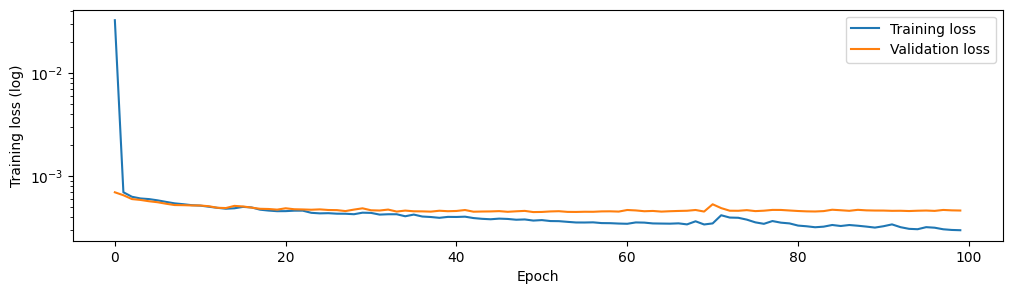

In [15]:
plt.figure(figsize = (12,3))
plt.semilogy(train_losses, label = 'Training loss')
plt.semilogy(val_losses, label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Training loss (log)')
plt.legend()
plt.show()

In [16]:
### Should make some code here

In [143]:
train_latents = []
train_recon = []
train_xs = []
train_recon_actual = []

model.eval()

with torch.no_grad():

    for batch in train_loader:

        acc = batch["acc"].to(device)
        strain = batch["strain"].to(device)

        x = torch.cat(
            [acc, strain],
            dim=1
        )

        recon, latent, _ = model(x)

        train_xs.append(x.cpu())

        train_latents.append(
            latent.cpu()
        )
        train_recon_actual.append(
            recon.cpu()
        )

        train_recon.append(
            ((recon-x)**2).cpu()
        )

train_latents = torch.cat(
    train_latents
)
train_xs = torch.cat(train_xs)

train_recon = torch.cat(
    train_recon
)
train_recon_actual = torch.cat(
    train_recon_actual
)

In [18]:
"""latent_mean = train_latents.mean(
    dim=0
)

latent_std = train_latents.std(
    dim=0
)"""

'latent_mean = train_latents.mean(\n    dim=0\n)\n\nlatent_std = train_latents.std(\n    dim=0\n)'

In [144]:
test_latents = []
test_recon = []
test_xs = []
test_recon_actual = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        acc = batch["acc"].to(device)
        strain = batch["strain"].to(device)

        x = torch.cat(
            [acc, strain],
            dim=1
        )

        recon, latent, _ = model(x)

        test_xs.append(x.cpu())

        test_recon_actual.append(
            recon.cpu()
        )

        test_latents.append(
            latent.cpu()
        )
        test_recon.append(
            ((recon-x)**2).cpu()
        )

test_latents = torch.cat(
    test_latents
)
test_xs = torch.cat(test_xs)

test_recon = torch.cat(
    test_recon
)

test_recon_actual = torch.cat(
    test_recon_actual
)

In [145]:
"""distance = [(
    (
        latent
        - latent_mean
    )**2
    /
    (
        latent_std + 1e-8
    )**2
).mean(dim=0) for latent in test_latents]"""

'distance = [(\n    (\n        latent\n        - latent_mean\n    )**2\n    /\n    (\n        latent_std + 1e-8\n    )**2\n).mean(dim=0) for latent in test_latents]'

In [146]:
mean_train_recon = (train_recon.mean(dim=(1,2)))

mean_test_recon = (test_recon.mean(dim=(1,2)))


In [147]:
from sklearn.decomposition import PCA
import seaborn as sns


In [148]:
pca = PCA(2)

train_pca = pca.fit_transform(train_latents)
test_pca = pca.transform(test_latents)

In [149]:
mean_test_recon.max()

tensor(0.4674)

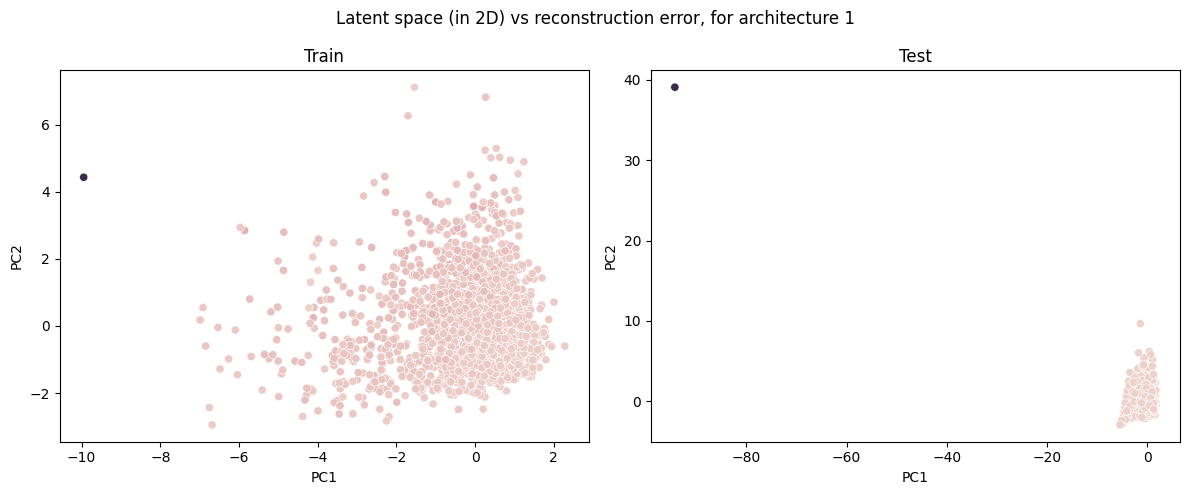

In [150]:
plt.figure(figsize = (12,5))
plt.subplot(121)
sns.scatterplot(x = train_pca[:,0], y =  train_pca[:,1],hue = mean_train_recon, alpha = 0.95, legend = False)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('Train')
plt.subplot(122)
sns.scatterplot(x = test_pca[:,0], y =  test_pca[:,1],hue = mean_test_recon, alpha = 0.95, legend = False)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('Test')
plt.suptitle('Latent space (in 2D) vs reconstruction error, for architecture 1')
plt.tight_layout()
plt.show()

In [151]:
np.linalg.norm(train_recon,axis = 1).argmax(axis = 1)

array([22, 13, 37, ...,  4, 20, 29], dtype=int64)

In [152]:
counts_train = torch.from_numpy(
    np.linalg.norm(train_recon, axis=1).argmax(axis=1)
).bincount()

counts_test = torch.from_numpy(
    np.linalg.norm(test_recon, axis=1).argmax(axis=1)
).bincount()

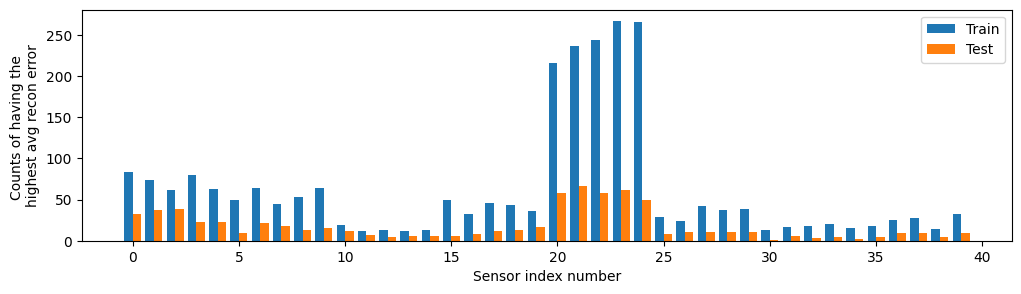

In [153]:
x = np.arange(len(counts_train))
w = 0.4

plt.figure(figsize=(12,3))

plt.bar(x - w/2, counts_train, width=w, label='Train')
plt.bar(x + w/2, counts_test, width=w, label='Test')

plt.legend()
plt.xlabel('Sensor index number')
plt.ylabel('Counts of having the \nhighest avg recon error')

plt.show()

In [154]:
idx_num = 21

train_recon_max = train_recon[:,:,idx_num].mean(axis = 1)
test_recon_max = test_recon[:,:,idx_num].mean(axis = 1)


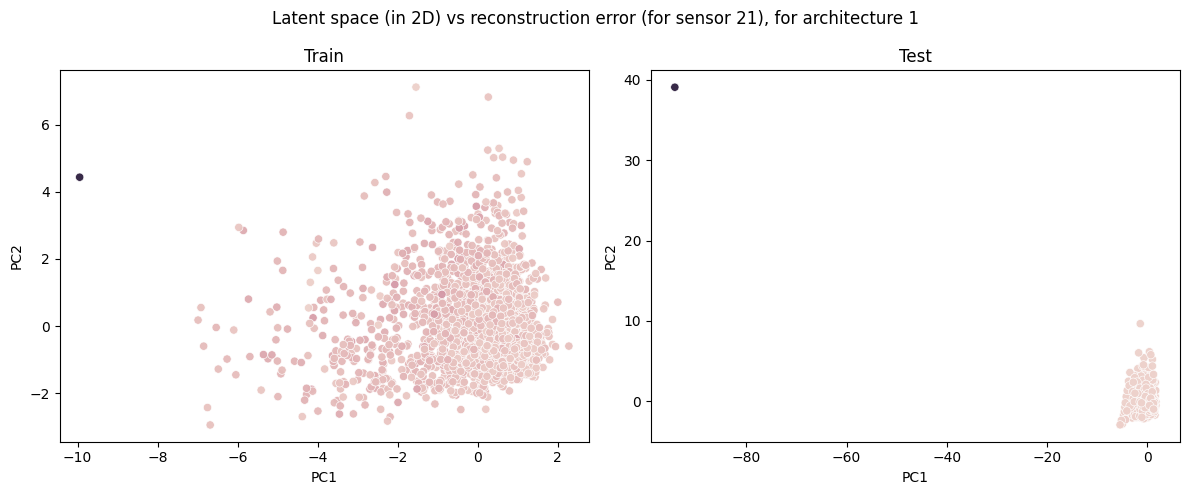

In [155]:
plt.figure(figsize = (12,5))
plt.subplot(121)
sns.scatterplot(x = train_pca[:,0], y =  train_pca[:,1],hue = train_recon_max, alpha = 0.95, legend = False)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim(train_pca[:,0].min()-0.5,train_pca[:,0].max()+0.5)
plt.ylim(train_pca[:,1].min()-0.5,train_pca[:,1].max()+0.5)
plt.title('Train')
plt.subplot(122)
sns.scatterplot(x = test_pca[:,0], y =  test_pca[:,1],hue = test_recon_max, alpha = 0.95, legend = False)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('Test')
plt.suptitle('Latent space (in 2D) vs reconstruction error (for sensor 21), for architecture 1')
plt.tight_layout()
plt.show()

In [162]:
#Wanting qualitative plot

train_idx,test_idx =train_recon_max.argmax(), test_recon_max.argmax()

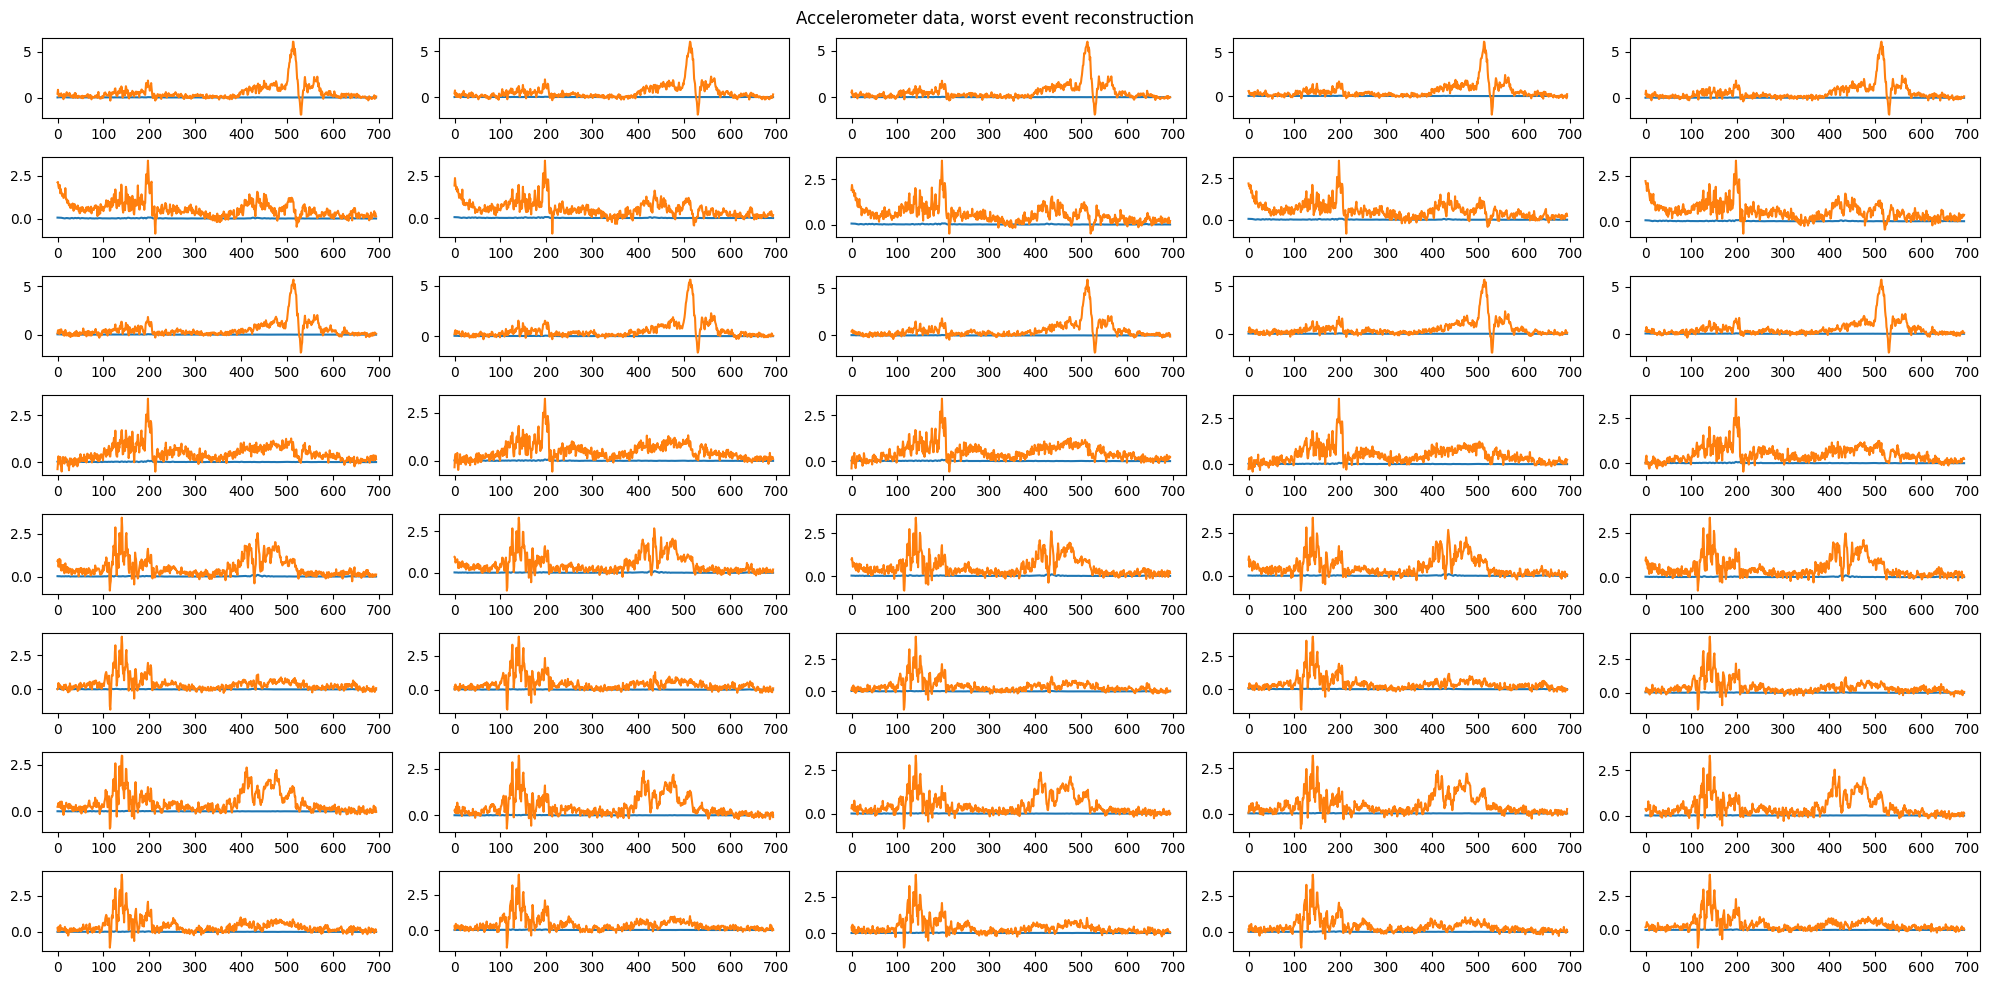

In [165]:
plt.figure(figsize = (20,10))
for i in range(40):
    plt.subplot(8,5,i+1)
    plt.plot(test_xs[test_idx,:-200,i])
    plt.plot(test_recon_actual[test_idx,:-200,i])

plt.suptitle('Accelerometer data, worst event reconstruction')
plt.tight_layout()
plt.show()

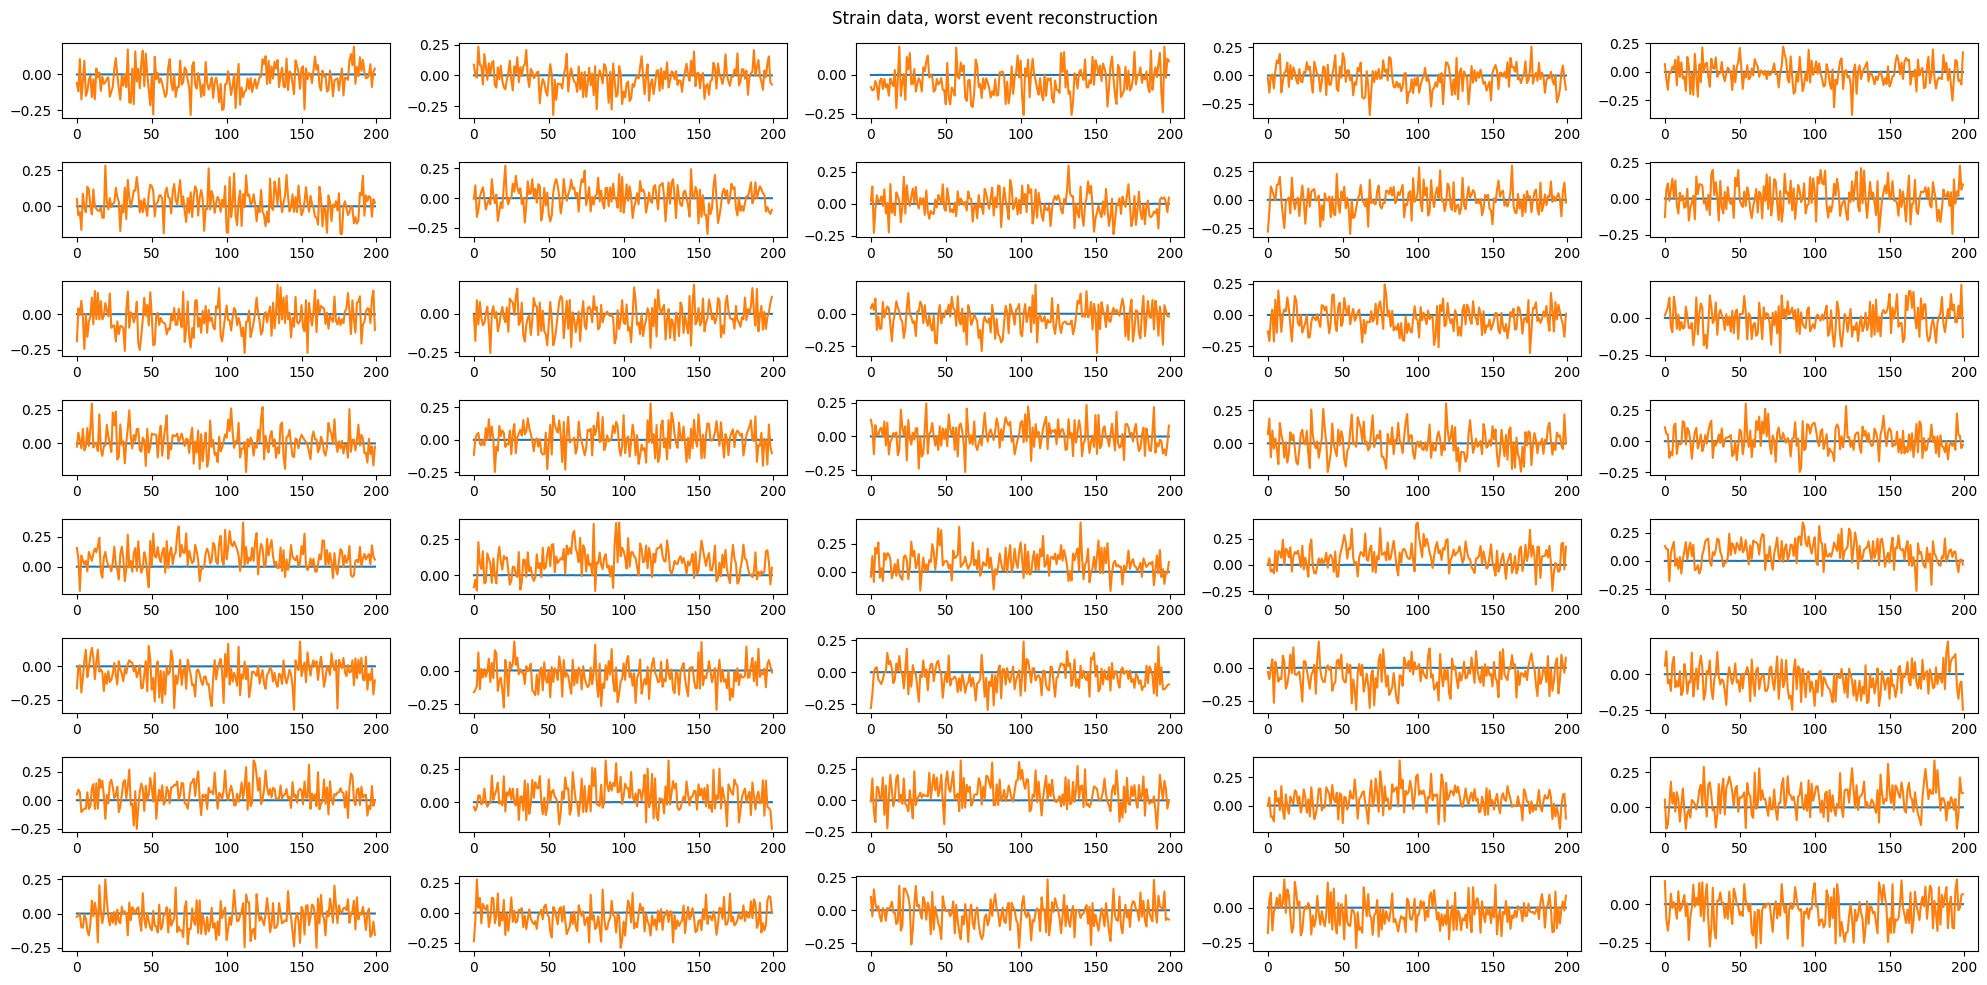

In [166]:
plt.figure(figsize = (20,10))
for i in range(40):
    plt.subplot(8,5,i+1)
    plt.plot(test_xs[test_idx,-200:,i])
    plt.plot(test_recon_actual[test_idx,-200:,i])

plt.suptitle('Strain data, worst event reconstruction')
plt.tight_layout()
plt.show()

In [167]:
#Wanting qualitative plot

train_idx,test_idx =train_recon_max.argmin(), test_recon_max.argmin()

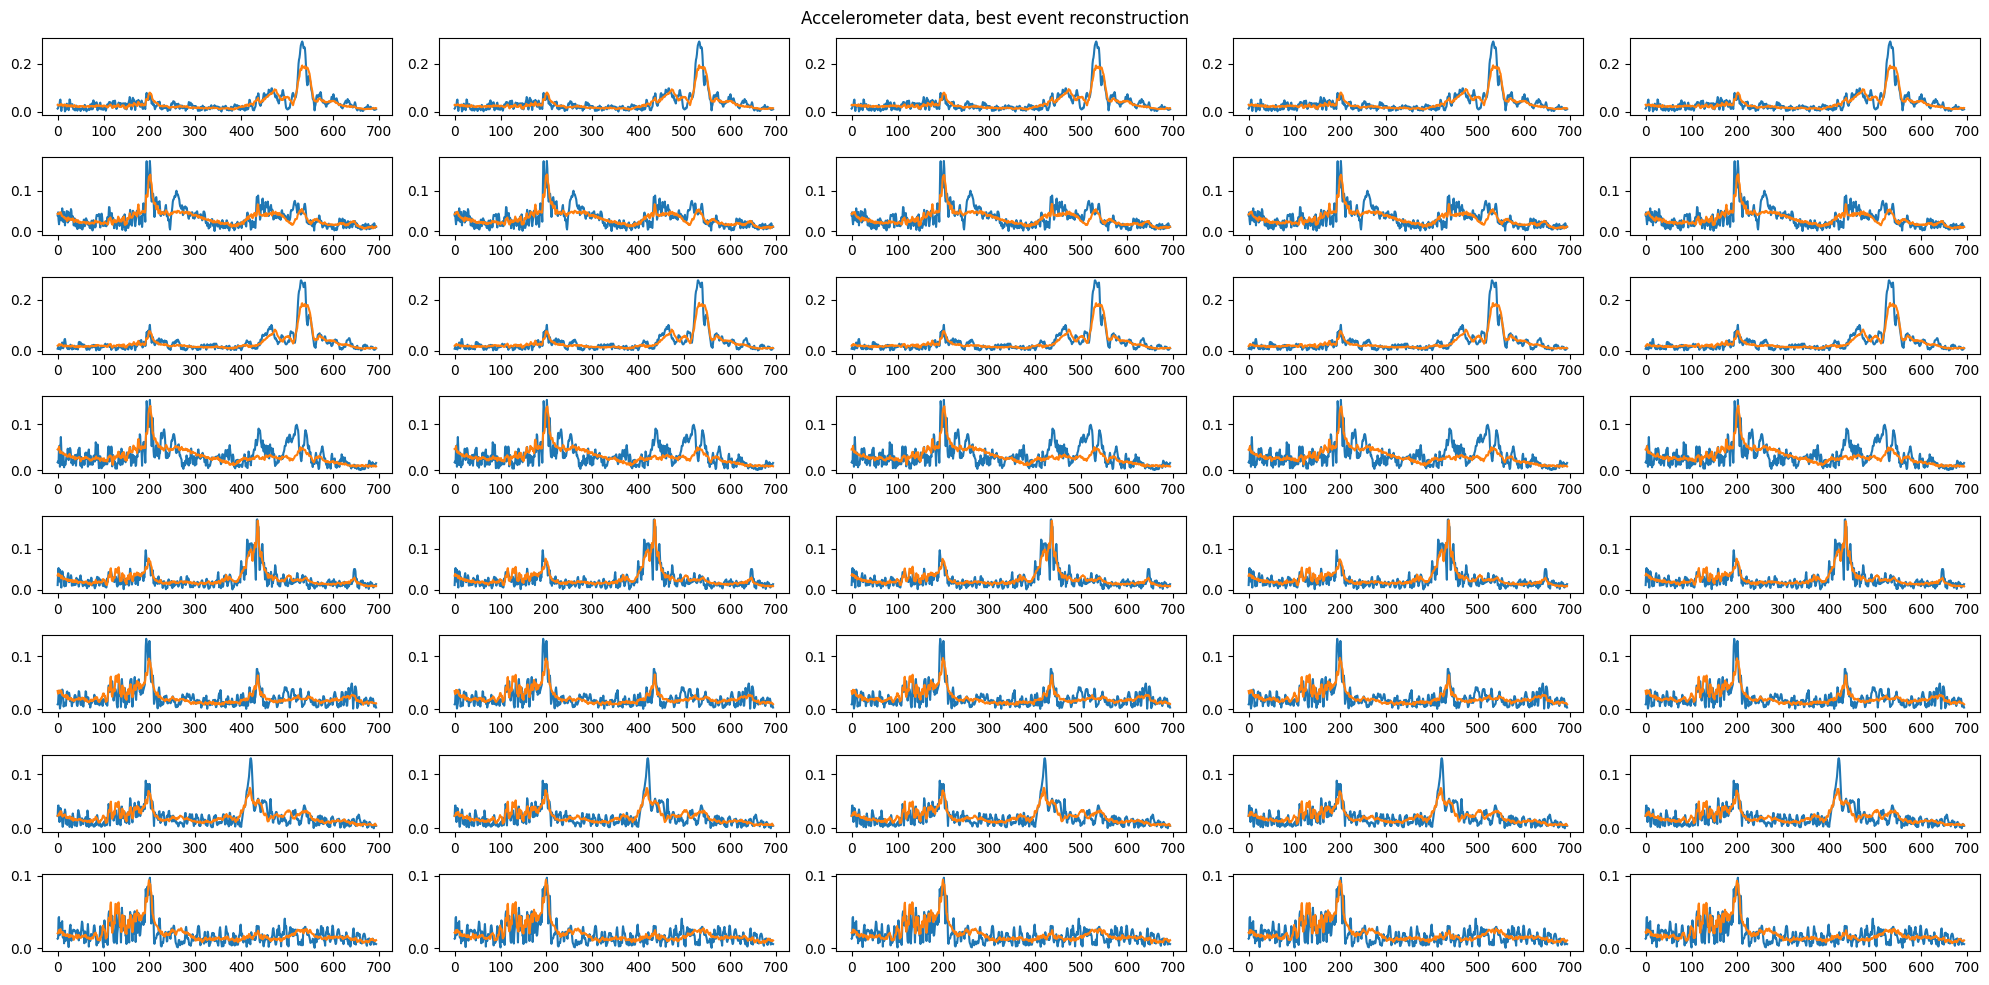

In [170]:
plt.figure(figsize = (20,10))
for i in range(40):
    plt.subplot(8,5,i+1)
    plt.plot(test_xs[test_idx,:-200,i])
    plt.plot(test_recon_actual[test_idx,:-200,i])

plt.suptitle('Accelerometer data, best event reconstruction')
plt.tight_layout()
plt.show()

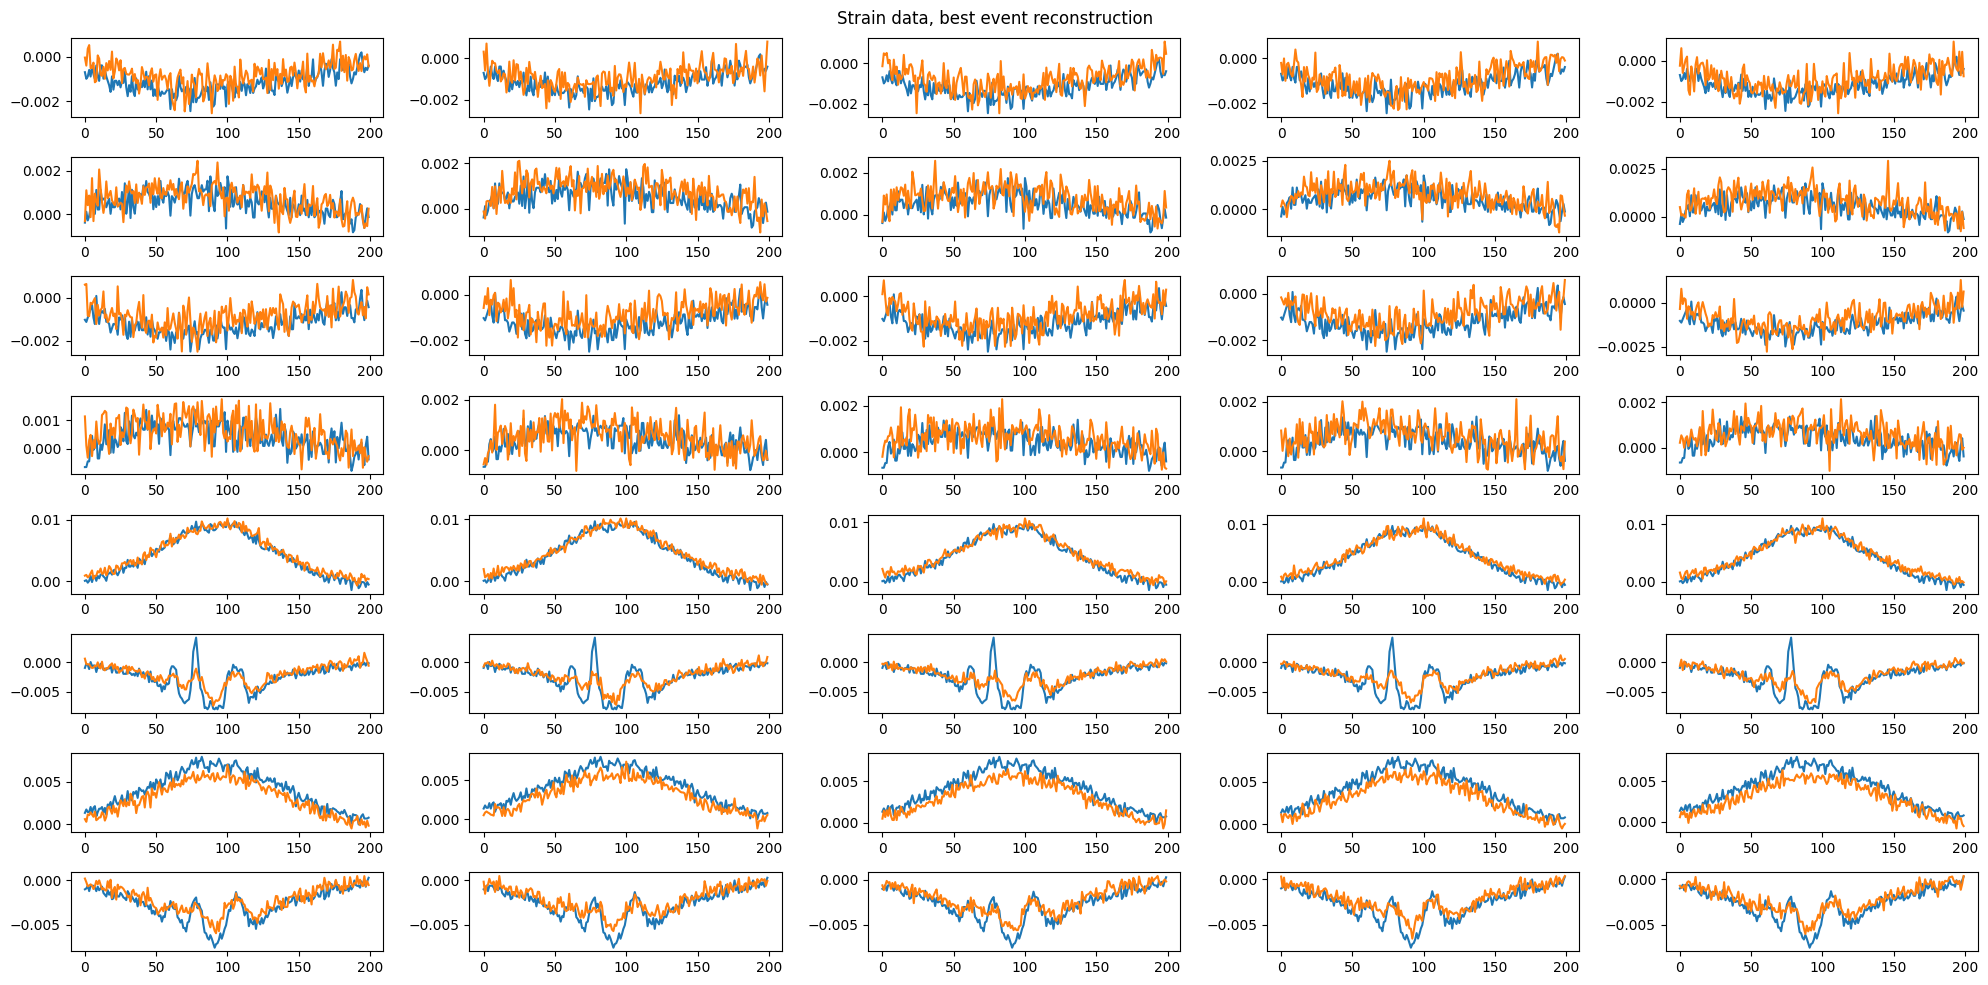

In [171]:
plt.figure(figsize = (20,10))
for i in range(40):
    plt.subplot(8,5,i+1)
    plt.plot(test_xs[test_idx,-200:,i])
    plt.plot(test_recon_actual[test_idx,-200:,i])

plt.suptitle('Strain data, best event reconstruction')
plt.tight_layout()
plt.show()